Download stock prices of 5 magnificent companies from Yahoo Finance

In [2]:
#Import libraries
 
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

In [3]:
#Set the 5-year window: from 5 years ago until today
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=5)
print (start_date)
print (end_date)
 
#List of tickers to download (the Magnificent 5)
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]

2021-05-01 08:31:24.499150
2026-05-01 08:31:24.499150


In [4]:
#Download daily data for each ticker in a loop, clean the columns,and collect the dataframes
 
frames = []
for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    #yfinance returns columns as a MultiIndex — made them to a single level
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data["Ticker"] = ticker
    frames.append(data)
    
#print (frames)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Data Exploration and Data Cleaning

In [5]:
#Combine the 5 dataframes into one and move Date from the index into a column
 
df_price = pd.concat(frames).reset_index()
df_price = df_price[["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]]
df_price

Price,Date,Ticker,Open,High,Low,Close,Volume
0,2021-05-03,AAPL,128.606416,130.583642,128.401886,129.093414,75135100
1,2021-05-04,AAPL,127.778479,128.070680,123.405233,124.525330,137564700
2,2021-05-05,AAPL,125.840231,127.057725,124.642220,124.768845,84000900
3,2021-05-06,AAPL,124.564305,126.375938,123.824067,126.366203,78128300
4,2021-05-07,AAPL,127.663821,128.063827,126.327171,127.039406,78973300
...,...,...,...,...,...,...,...
6270,2026-04-24,META,660.320007,680.669983,653.840027,675.030029,13348300
6271,2026-04-27,META,671.000000,682.500000,670.840027,678.619995,12805200
6272,2026-04-28,META,674.239990,678.179993,665.630005,671.340027,10606800
6273,2026-04-29,META,668.909973,674.250000,663.809998,669.119995,18947500


In [6]:
# Save the raw dataset to CSV
 
df_price.to_csv("Magnificent5_stockprice.csv", index=False)
df_price

Price,Date,Ticker,Open,High,Low,Close,Volume
0,2021-05-03,AAPL,128.606416,130.583642,128.401886,129.093414,75135100
1,2021-05-04,AAPL,127.778479,128.070680,123.405233,124.525330,137564700
2,2021-05-05,AAPL,125.840231,127.057725,124.642220,124.768845,84000900
3,2021-05-06,AAPL,124.564305,126.375938,123.824067,126.366203,78128300
4,2021-05-07,AAPL,127.663821,128.063827,126.327171,127.039406,78973300
...,...,...,...,...,...,...,...
6270,2026-04-24,META,660.320007,680.669983,653.840027,675.030029,13348300
6271,2026-04-27,META,671.000000,682.500000,670.840027,678.619995,12805200
6272,2026-04-28,META,674.239990,678.179993,665.630005,671.340027,10606800
6273,2026-04-29,META,668.909973,674.250000,663.809998,669.119995,18947500


In [7]:
#Read it back in and check the first few rows
 
df_price = pd.read_csv("Magnificent5_stockprice.csv")
df_price.head()

,Date,Ticker,Open,High,Low,Close,Volume
0,2021-05-03,AAPL,128.606416,130.583642,128.401886,129.093414,75135100
1,2021-05-04,AAPL,127.778479,128.070680,123.405233,124.525330,137564700
2,2021-05-05,AAPL,125.840231,127.057725,124.642220,124.768845,84000900
3,2021-05-06,AAPL,124.564305,126.375938,123.824067,126.366203,78128300
4,2021-05-07,AAPL,127.663821,128.063827,126.327171,127.039406,78973300


In [8]:
#Check the overall size of the dataset (rows, columns)
 
df_price.shape

(6275, 7)

In [9]:
#Quick look at the dataframe information
 
df_price.info

<bound method DataFrame.info of             Date Ticker        Open        High         Low       Close  \
0     2021-05-03   AAPL  128.606416  130.583642  128.401886  129.093414   
1     2021-05-04   AAPL  127.778479  128.070680  123.405233  124.525330   
2     2021-05-05   AAPL  125.840231  127.057725  124.642220  124.768845   
3     2021-05-06   AAPL  124.564305  126.375938  123.824067  126.366203   
4     2021-05-07   AAPL  127.663821  128.063827  126.327171  127.039406   
...          ...    ...         ...         ...         ...         ...   
6270  2026-04-24   META  660.320007  680.669983  653.840027  675.030029   
6271  2026-04-27   META  671.000000  682.500000  670.840027  678.619995   
6272  2026-04-28   META  674.239990  678.179993  665.630005  671.340027   
6273  2026-04-29   META  668.909973  674.250000  663.809998  669.119995   
6274  2026-04-30   META  619.320007  620.849976  600.000000  611.909973   

         Volume  
0      75135100  
1     137564700  
2      840009

In [10]:
# Check the data types of each column
 
df_price.dtypes

Date       object
Ticker     object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

In [11]:
#Convert Date from string to datetime type
 
df_price["Date"] = pd.to_datetime(df_price["Date"])
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6275 entries, 0 to 6274
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6275 non-null   datetime64[ns]
 1   Ticker  6275 non-null   object        
 2   Open    6275 non-null   float64       
 3   High    6275 non-null   float64       
 4   Low     6275 non-null   float64       
 5   Close   6275 non-null   float64       
 6   Volume  6275 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 343.3+ KB


In [12]:
#Confirm the earliest and latest dates in the dataset
 
df_price["Date"].min()
df_price["Date"].max()

Timestamp('2026-04-30 00:00:00')

In [13]:
#Count how many unique trading days are in the dataset
 
df_price["Date"].nunique()

1255

In [14]:
# Check for missing values and duplicate rows
 
print(df_price.isna().sum())
print(df_price.isna().any(axis=1).sum())
print(df_price.duplicated().sum())

Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
0
0


In [15]:
#See the statistics summary for the numeric columns
 
df_price.describe()

,Date,Open,High,Low,Close,Volume
count,6275,6275.000000,6275.000000,6275.000000,6275.000000,6.275000e+03
mean,2023-10-29 15:01:51.872509952,255.851450,258.750865,252.904748,255.907050,4.034084e+07
min,2021-05-03 00:00:00,82.800003,83.480003,81.430000,81.820000,4.726100e+06
25%,2022-07-29 00:00:00,149.993556,152.093045,148.147346,150.208809,2.163615e+07
50%,2023-10-27 00:00:00,206.042994,209.179993,203.582368,206.658249,3.294150e+07
75%,2025-01-30 00:00:00,319.061333,322.487007,314.533497,318.459976,5.130280e+07
max,2026-04-30 00:00:00,789.296390,794.384398,778.990557,788.148987,3.186799e+08
std,NaN,146.750521,148.201554,144.995823,146.613175,2.688732e+07


In [16]:
#Row-level value counts
 
print(df_price.value_counts())

Date        Ticker  Open        High        Low         Close       Volume  
2021-05-03  AAPL    128.606416  130.583642  128.401886  129.093414  75135100    1
2024-08-30  AMZN    172.779999  178.899994  172.600006  178.500000  43429400    1
2024-08-29  MSFT    410.142562  417.170344  405.852744  408.343597  17045200    1
            META    516.066824  524.170007  512.716197  515.241577  8317400     1
            GOOGL   163.150156  164.798442  159.118817  160.638016  19699800    1
                                                                               ..
2022-12-27  MSFT    232.595317  232.819430  229.798721  230.899826  16688600    1
            META    117.011752  117.676534  115.146393  115.969925  21392300    1
            GOOGL   88.072083   88.210935   86.296755   86.673637   20097300    1
            AMZN    84.970001   85.349998   83.000000   83.040001   57284000    1
2026-04-30  MSFT    410.809998  414.420013  398.010010  407.779999  70783800    1
Name: count, Length: 

In [17]:
# Quick range check
print(df_price["Close"].min())
print(df_price["Close"].max())
print(df_price["Volume"].min())
print(df_price["Volume"].max())

81.81999969482422
788.1489868164062
4726100
318679900


In [18]:
# Sort by Date
df_price = df_price.sort_values(by=["Date", "Ticker"]).reset_index(drop=True)
df_price

,Date,Ticker,Open,High,Low,Close,Volume
0,2021-05-03,AAPL,128.606416,130.583642,128.401886,129.093414,75135100
1,2021-05-03,AMZN,174.236496,174.332504,168.634995,169.324493,117510000
2,2021-05-03,GOOGL,117.276217,118.101397,115.817773,116.193665,28242000
3,2021-05-03,META,323.630311,325.991753,319.334009,320.068237,18719500
4,2021-05-03,MSFT,243.152398,244.063991,240.964603,241.674683,19626600
...,...,...,...,...,...,...,...
6270,2026-04-30,AAPL,270.500000,276.000000,268.140015,271.350006,90134300
6271,2026-04-30,AMZN,273.170013,273.880005,256.160004,265.059998,100869700
6272,2026-04-30,GOOGL,374.070007,385.839996,365.820007,384.799988,71949900
6273,2026-04-30,META,619.320007,620.849976,600.000000,611.909973,52674900


In [19]:
#Save the cleaned dataset
 
df_price.to_csv("Magnificent5_stockprice_clean.csv", index=False)

Nasdaq Data Exploration and Data Cleaning

In [20]:
# Import libraries
 
import pandas as pd

In [21]:
#Load the NASDAQ Stock Screener CSV downloaded from nasdaq.com
 
df_nasdaq = pd.read_csv("nasdaq_screener_1777050489651.csv")
df_nasdaq.head()

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry
0,A,Agilent Technologies Inc. Common Stock,$116.12,1.70,1.486%,3.281578e+10,United States,1999.0,406707,Industrials,Biotechnology: Laboratory Analytical Instruments
1,AA,Alcoa Corporation Common Stock,$65.98,0.61,0.933%,1.740965e+10,United States,2016.0,1099056,Industrials,Aluminum
2,AACB,Artius II Acquisition Inc. Class A Ordinary Sh...,$10.38,0.01,0.096%,0.000000e+00,United States,2025.0,43434,NaN,NaN
3,AACBR,Artius II Acquisition Inc. Rights,$0.34,0.00,0.00%,0.000000e+00,United States,2025.0,13,NaN,NaN
4,AACBU,Artius II Acquisition Inc. Units,$10.53,0.00,0.00%,0.000000e+00,United States,2025.0,1,Finance,Blank Checks


In [22]:
# Check the overall size of the dataset
 
df_nasdaq.shape

(7047, 11)

In [23]:
# Quick look at dataframe
 
df_nasdaq.info

<bound method DataFrame.info of      Symbol                                               Name Last Sale  \
0         A             Agilent Technologies Inc. Common Stock   $116.12   
1        AA                    Alcoa Corporation Common Stock     $65.98   
2      AACB  Artius II Acquisition Inc. Class A Ordinary Sh...    $10.38   
3     AACBR                  Artius II Acquisition Inc. Rights     $0.34   
4     AACBU                   Artius II Acquisition Inc. Units    $10.53   
...     ...                                                ...       ...   
7042   ZVIA                     Zevia PBC Class A Common Stock     $1.29   
7043   ZVRA               Zevra Therapeutics Inc. Common Stock     $9.92   
7044    ZWS  Zurn Elkay Water Solutions Corporation Common ...    $52.57   
7045   ZYBT  Zhengye Biotechnology Holding Limited Class A ...   $0.9202   
7046   ZYME                        Zymeworks Inc. Common Stock    $28.15   

      Net Change % Change    Market Cap        Country 

In [24]:
# Check the data types of each column
 
df_nasdaq.dtypes

Symbol         object
Name           object
Last Sale      object
Net Change    float64
% Change       object
Market Cap    float64
Country        object
IPO Year      float64
Volume          int64
Sector         object
Industry       object
dtype: object

In [25]:
# Last Sale was a string like "$116.12" — strip the dollar sign and convert to float
 
df_nasdaq["Last Sale"] = df_nasdaq["Last Sale"].str.replace("$", "", regex=False).astype(float)

In [26]:
print(df_nasdaq["Last Sale"])

0       116.1200
1        65.9800
2        10.3800
3         0.3400
4        10.5300
          ...   
7042      1.2900
7043      9.9200
7044     52.5700
7045      0.9202
7046     28.1500
Name: Last Sale, Length: 7047, dtype: float64


In [27]:
# % Change was a string like "1.486%" — strip the percent sign and convert to float
 
df_nasdaq["% Change"] = df_nasdaq["% Change"].str.replace("%", "", regex=False).astype(float)

In [28]:
print(df_nasdaq["% Change"])

0       1.486
1       0.933
2       0.096
3       0.000
4       0.000
        ...  
7042    0.781
7043   -1.879
7044   -0.360
7045    0.011
7046    2.625
Name: % Change, Length: 7047, dtype: float64


In [29]:
#Check the data types again to confirm the cleaning worked
 
df_nasdaq.dtypes

Symbol         object
Name           object
Last Sale     float64
Net Change    float64
% Change      float64
Market Cap    float64
Country        object
IPO Year      float64
Volume          int64
Sector         object
Industry       object
dtype: object

In [30]:
#Confirm the data
 
df_nasdaq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7047 entries, 0 to 7046
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Symbol      7046 non-null   object 
 1   Name        7047 non-null   object 
 2   Last Sale   7047 non-null   float64
 3   Net Change  7047 non-null   float64
 4   % Change    7047 non-null   float64
 5   Market Cap  6649 non-null   float64
 6   Country     6780 non-null   object 
 7   IPO Year    4030 non-null   float64
 8   Volume      7047 non-null   int64  
 9   Sector      6311 non-null   object 
 10  Industry    6310 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 605.7+ KB


In [31]:
#To check summary statistics for the numeric columns
 
df_nasdaq.describe()

,Last Sale,Net Change,% Change,Market Cap,IPO Year,Volume
count,7047.000000,7047.000000,7047.000000,6.649000e+03,4030.000000,7.047000e+03
mean,146.263224,-0.347754,0.133483,1.485410e+10,2015.616377,1.153512e+06
std,8378.914870,34.278173,5.358675,1.343026e+11,10.998081,2.538828e+07
min,0.001500,-2865.000000,-93.300000,0.000000e+00,1925.000000,1.000000e+00
25%,3.953300,-0.080000,-0.920500,2.786747e+07,2012.000000,1.070800e+04
50%,14.035000,0.000000,0.000000,4.906272e+08,2020.000000,8.021900e+04
75%,35.220000,0.095000,0.977500,3.795452e+09,2024.000000,3.712385e+05
max,703300.000000,116.570000,174.503000,5.108591e+12,2026.000000,2.091383e+09


In [32]:
# How many companies in each Sector
 
print(df_nasdaq["Sector"].value_counts(dropna=False))

Sector
Finance                   1573
Health Care               1093
Consumer Discretionary    1029
Technology                 770
NaN                        736
Industrials                620
Real Estate                393
Energy                     196
Utilities                  175
Consumer Staples           151
Basic Materials            142
Telecommunications         106
Miscellaneous               63
Name: count, dtype: int64


In [33]:
#Check for missing values and duplicate rows
print(df_nasdaq.isna().sum())
print(df_nasdaq.isna().any(axis=1).sum())
print(df_nasdaq.duplicated().sum())

Symbol           1
Name             0
Last Sale        0
Net Change       0
% Change         0
Market Cap     398
Country        267
IPO Year      3017
Volume           0
Sector         736
Industry       737
dtype: int64
3507
0


In [34]:
#Drop the single malformed row where Symbol is missing
 
df_nasdaq = df_nasdaq.dropna(subset=["Symbol"]).reset_index(drop=True)
df_nasdaq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7046 entries, 0 to 7045
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Symbol      7046 non-null   object 
 1   Name        7046 non-null   object 
 2   Last Sale   7046 non-null   float64
 3   Net Change  7046 non-null   float64
 4   % Change    7046 non-null   float64
 5   Market Cap  6648 non-null   float64
 6   Country     6779 non-null   object 
 7   IPO Year    4029 non-null   float64
 8   Volume      7046 non-null   int64  
 9   Sector      6310 non-null   object 
 10  Industry    6309 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 605.6+ KB


In [35]:
print("Unique industries:", df_nasdaq["Industry"].nunique())

Unique industries: 152


In [36]:
#Sort alphabetically by Symbol for a tidy output order
 
df_nasdaq = df_nasdaq.sort_values(by="Symbol").reset_index(drop=True)
#df_nasdaq

In [37]:
#Save the cleaned dataset
 
df_nasdaq.to_csv("NASDAQ_screener_clean.csv", index=False)

Insight 1 — Profile of the Magnificent 5 (Descriptive)
Research question: Who are the Magnificent 5 in numbers, and what are they as companies?
Datasets: Magnificent5_stockprice_clean.csv (Dataset 1) and NASDAQ_screener_clean.csv(Dataset 2)

In [38]:
#Function: safely read a CSV with friendly error messages, exits on failure
def read_csv(filepath, **kwargs):
    """Load a csv with friendly error messages. Exits the code on failure"""
    try:
        return pd.read_csv(filepath, **kwargs)
    except FileNotFoundError:
        print(f"Error: file'{filepath}' not found. please ensure it's in the same working folder")
    except pd.errors.EmptyDataError:
        print(f"Error: file '{filepath}' is empty.")
    except pd.errors.ParserError as e:
        print(f"Error parsing '{filepath}': {e}")
    exit()

In [39]:
#Load both datasets
prices = read_csv("Magnificent5_stockprice_clean.csv", parse_dates=["Date"])
screener = read_csv("NASDAQ_screener_clean.csv")

In [40]:
# List of tickers to analyse
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]

Visual 1: Cumulative return line chart (each stock normalised to start at $1)

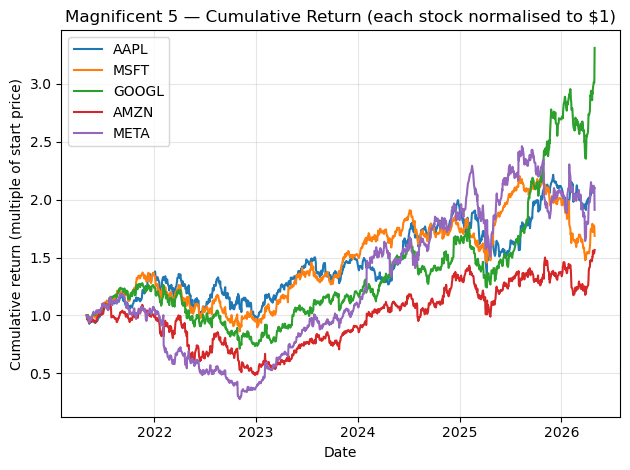

In [41]:
plt.Figure(figsize=(10,6))

for ticker in tickers:
    series = prices.loc[prices["Ticker"]==ticker, ["Date","Close"]].reset_index(drop=True)
    #print(series)
    series["Normalized"] = series["Close"]/series["Close"].loc[0]
    #print(series["Normalized"])
    plt.plot(series["Date"],series["Normalized"],label=ticker)

plt.title("Magnificent 5 — Cumulative Return (each stock normalised to $1)")
plt.xlabel("Date")
plt.ylabel("Cumulative return (multiple of start price)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("insight1_cumulative_return.png", dpi=150)
plt.show()

In [42]:
# Function: total return over the full window, expressed as a percentage
def total_return(close_prices):
    return (close_prices.iloc[-1]/close_prices.iloc[0]-1)*100

In [43]:
# Function: average daily return, expressed as a percentage
def average_daily_return(close_prices):
    daily_return = close_prices.pct_change().dropna()
    return daily_return.mean()*100

In [44]:
# Function: annualised volatility, expressed as a percentage
# 252 is the standard number of trading days per year used in finance
def cumulative_annualized_volatility(close_prices):
    daily_return = close_prices.pct_change().dropna()
    return daily_return.std()*np.sqrt(252)*100

In [45]:
# Build a profile row for each ticker by looping over the list
profile_rows = []
for ticker in tickers:
    closes = prices.loc[prices["Ticker"]==ticker, "Close"].reset_index(drop=True)
    #print(daily_return(closes))
    profile_rows.append({
        "Ticker" : ticker,
        "Total Return %" : round(total_return(closes),1),
        "Average Daily Return %" : round(average_daily_return(closes),2),
        "Cumulative Annualized Volatility %" : round(cumulative_annualized_volatility(closes),1)
    }
    )
#print (profile_rows)
profile_df = pd.DataFrame(profile_rows)
#profile_df

In [46]:
# Pull the matching Dataset 2 attributes (Sector, Industry, Market Cap) for each ticker
criteria = screener.loc[
    screener["Symbol"].isin(tickers), [
        "Symbol","Sector","Industry","Market Cap"
    ]
]
criteria = criteria.rename(columns={"Symbol":"Ticker"})
criteria

,Ticker,Sector,Industry,Market Cap
19,AAPL,Technology,Computer Manufacturing,3.969193e+12
393,AMZN,Consumer Discretionary,Catalog/Specialty Distribution,2.816217e+12
2780,GOOGL,Technology,Computer Software: Programming Data Processing,4.156408e+12
3978,META,Technology,Computer Software: Programming Data Processing,1.715378e+12
4174,MSFT,Technology,Computer Software: Prepackaged Software,3.113603e+12


In [47]:
# Merge Dataset 1 stats with Dataset 2 attributes into one 5-row profile table
profile = pd.merge(profile_df,criteria,on='Ticker',how='left')
profile

,Ticker,Total Return %,Average Daily Return %,Cumulative Annualized Volatility %,Sector,Industry,Market Cap
0,AAPL,110.2,0.07,27.5,Technology,Computer Manufacturing,3.969193e+12
1,MSFT,68.7,0.06,26.4,Technology,Computer Software: Prepackaged Software,3.113603e+12
2,GOOGL,231.2,0.11,31.2,Technology,Computer Software: Programming Data Processing,4.156408e+12
3,AMZN,56.5,0.06,35.5,Consumer Discretionary,Catalog/Specialty Distribution,2.816217e+12
4,META,91.2,0.09,44.0,Technology,Computer Software: Programming Data Processing,1.715378e+12


In [48]:
#Format Market Cap as billions of dollars
profile['Market Cap ($B)'] = (profile["Market Cap"]/pow(10,9)).round(0).astype(int)
profile

,Ticker,Total Return %,Average Daily Return %,Cumulative Annualized Volatility %,Sector,Industry,Market Cap,Market Cap ($B)
0,AAPL,110.2,0.07,27.5,Technology,Computer Manufacturing,3.969193e+12,3969
1,MSFT,68.7,0.06,26.4,Technology,Computer Software: Prepackaged Software,3.113603e+12,3114
2,GOOGL,231.2,0.11,31.2,Technology,Computer Software: Programming Data Processing,4.156408e+12,4156
3,AMZN,56.5,0.06,35.5,Consumer Discretionary,Catalog/Specialty Distribution,2.816217e+12,2816
4,META,91.2,0.09,44.0,Technology,Computer Software: Programming Data Processing,1.715378e+12,1715


In [49]:
# Drop the unuse column
profile = profile.drop(columns=['Market Cap'])
profile

,Ticker,Total Return %,Average Daily Return %,Cumulative Annualized Volatility %,Sector,Industry,Market Cap ($B)
0,AAPL,110.2,0.07,27.5,Technology,Computer Manufacturing,3969
1,MSFT,68.7,0.06,26.4,Technology,Computer Software: Prepackaged Software,3114
2,GOOGL,231.2,0.11,31.2,Technology,Computer Software: Programming Data Processing,4156
3,AMZN,56.5,0.06,35.5,Consumer Discretionary,Catalog/Specialty Distribution,2816
4,META,91.2,0.09,44.0,Technology,Computer Software: Programming Data Processing,1715


In [50]:
# Reorder columns into a clean report-ready order
profile = profile[[
    "Ticker","Sector","Industry","Market Cap ($B)","Total Return %","Average Daily Return %", "Cumulative Annualized Volatility %"
]]
profile

,Ticker,Sector,Industry,Market Cap ($B),Total Return %,Average Daily Return %,Cumulative Annualized Volatility %
0,AAPL,Technology,Computer Manufacturing,3969,110.2,0.07,27.5
1,MSFT,Technology,Computer Software: Prepackaged Software,3114,68.7,0.06,26.4
2,GOOGL,Technology,Computer Software: Programming Data Processing,4156,231.2,0.11,31.2
3,AMZN,Consumer Discretionary,Catalog/Specialty Distribution,2816,56.5,0.06,35.5
4,META,Technology,Computer Software: Programming Data Processing,1715,91.2,0.09,44.0


In [51]:
# Save the profile table as a CSV for the report appendix
 
profile.to_csv("insight1_profile.csv", index=False)

Visual 2: Render the profile table as an image for embedding in the report

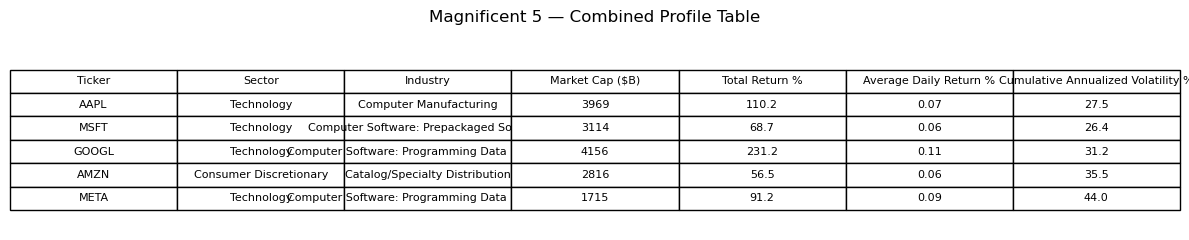

In [ ]:
# Column widths are set explicitly so the long Industry names fit cleanly
# and the header row is styled in dark blue with white bold text
fig,ax = plt.subplots(figsize=(12,2.5))
ax.axis("off")
table = ax.table(
    cellText = profile.values,
    colLabels=profile.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1,1.5)
plt.title("Magnificent 5 — Combined Profile Table",pad=20)
plt.tight_layout()
#plt.savefig("insight1_profile_table.png",dpi=150,bbox_inches="tight")
plt.show()

Insight 2 — Chi-Square Test of Independence
Research question: Are certain sectors significantly more likely to contain larger-market-cap companies than others?
Dataset: NASDAQ_screener_clean.csv (Dataset 2)

In [53]:
# Load the cleaned NASDAQ Screener dataset
 
screener = read_csv("NASDAQ_screener_clean.csv")

In [54]:
# Keep only rows where both Sector and Market Cap have values
 
screener = screener.dropna(subset=["Sector", "Market Cap"])
print(f"Number of companies in this analysis: {len(screener)}")

Number of companies in this analysis: 6307


In [55]:
# Function: give each company a market cap tier label based on its size
def get_market_cap_tier(market_cap):
    if market_cap >= 200_000_000_000:       # 200 billion or more
        return "Mega-Cap"
    elif market_cap >= 10_000_000_000:      # 10 billion to 200 billion
        return "Large-Cap"
    elif market_cap >= 2_000_000_000:       # 2 billion to 10 billion
        return "Mid-Cap"
    else:                                    # less than 2 billion
        return "Small-Cap"

In [56]:
# Decide whether to reject the null hypothesis at the 5% level
 
def isSignificant(p_val, alpha=0.05):

    if p_val < alpha:
        return print(f"{True}\nReject H₀ - the result is statistically significant")
    else:
        return print(f"{False}\nFail to reject H₀ - the result is not statistically significant")

In [57]:
# Add a new column called Market Cap Tier
# Applying the function, each company gets one of: Mega-Cap, Large-Cap, Mid-Cap, Small-Cap
 
screener["Market Cap Tier"] = screener["Market Cap"].apply(get_market_cap_tier)

In [58]:
# Build the contingency table to see how many companies fall in each combination of Sector and Tier
 
tier_order = ["Mega-Cap", "Large-Cap", "Mid-Cap", "Small-Cap"]
contingency = pd.crosstab(screener["Sector"], screener["Market Cap Tier"])
contingency = contingency[tier_order]
print("Contingency table:")
print(contingency)

Contingency table:
Market Cap Tier         Mega-Cap  Large-Cap  Mid-Cap  Small-Cap
Sector                                                         
Basic Materials                1         27       33         81
Consumer Discretionary         7        145      218        659
Consumer Staples               2         25       24        100
Energy                         4         41       52         99
Finance                       10        151      222       1188
Health Care                    8         88      147        849
Industrials                    4        149      145        322
Miscellaneous                  0          1       14         48
Real Estate                    3         64       93        233
Technology                    22        125      147        475
Telecommunications             4         20       19         63
Utilities                      0         66       57         52


In [59]:
# Run the chi-square test of independence
# It compares the actual (observed) counts with what we would expect
 
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")
#print(expected)

isSignificant(p_value)

Chi-square statistic: 416.86
Degrees of freedom: 33
p-value: 0.000000
True
Reject H₀ - the result is statistically significant


In [60]:
# Check the chi-square assumption: every expected count should be >= 5
# A common rule is that no more than 20% of cells may fall below 5
 
min_expected = expected.min()
cells_below_5 = (expected < 5).sum()
#print(cells_below_5)
total_cells = expected.size
#print(total_cells)
pct_below_5 = cells_below_5 / total_cells * 100
 
print(f"Minimum expected frequency: {min_expected:.2f}")
print(f"Cells with expected < 5: {cells_below_5} of {total_cells} ({pct_below_5:.1f}%)")

Minimum expected frequency: 0.65
Cells with expected < 5: 7 of 48 (14.6%)


In [61]:
# Calculate Cramer's V to show how strong the relationship is
# Cramer's V is between 0 (no relationship) and 1 (perfect relationship)
 
n = contingency.values.sum()
print(n)
rows, cols = contingency.shape
cramers_v = np.sqrt(chi2 / (n * (min(rows, cols) - 1)))
print(f"Cramer's V: {cramers_v:.3f}")

6307
Cramer's V: 0.148


Visual 1: Heatmap showing how observed counts differ from expected counts

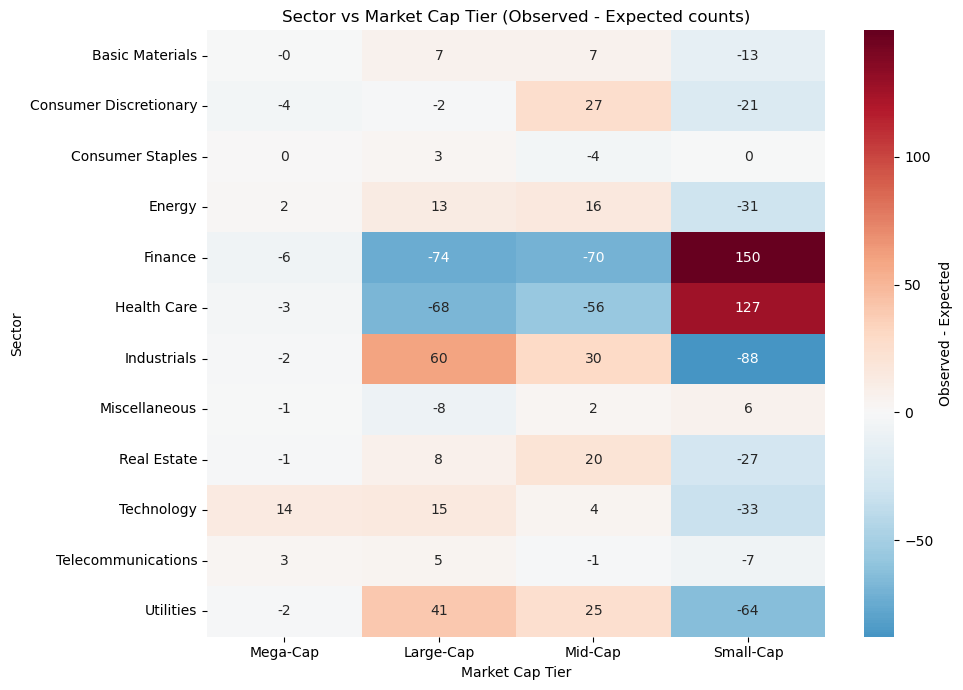

In [62]:
# Wrap the expected counts (a plain NumPy array from chi2_contingency) into a DataFrame, which is to subtract cell by cell with matching row/column names.
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
residuals = contingency - expected_df
#print(residuals)

plt.figure(figsize=(10, 7))
#Red cells = more companies than expected, Blue cells = fewer
sns.heatmap(residuals, annot=True, fmt=".0f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Observed - Expected"})
plt.title("Sector vs Market Cap Tier (Observed - Expected counts)")
plt.xlabel("Market Cap Tier")
plt.ylabel("Sector")
plt.tight_layout()
#plt.savefig("insight2_heatmap.png", dpi=150)
plt.show()  

Visual 2: Stacked bar chart showing what percent of each sector falls in each tier

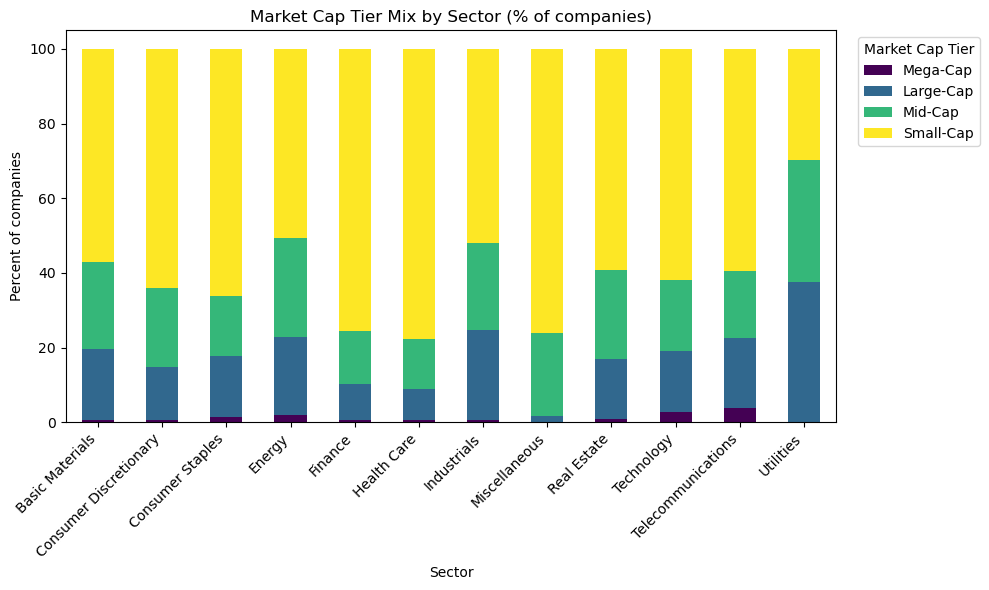

In [63]:
#Calculate what percent of each sector companies fall into what Market Cap Tier.
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
#print(contingency_pct)

# Plot one stacked bar for each sector, and segments are coloured by Market Cap Tier. 
contingency_pct.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Market Cap Tier Mix by Sector (% of companies)")
plt.ylabel("Percent of companies")
plt.xlabel("Sector")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Market Cap Tier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
#plt.savefig("insight2_stackedbar.png", dpi=150)
plt.show()

Insight 3 - One-Way ANOVA on Daily Returns by Company
Question: Do the Magnificent 5 have statistically different mean daily returns?
Dataset: Magnificent5_stockprice_clean.csv

In [64]:
# Load the cleaned Magnificent 5 stock data
 
prices = read_csv("Magnificent5_stockprice_clean.csv", parse_dates=["Date"])

In [65]:
# Function: compute daily returns from a series of closing prices
 
def get_daily_returns(close_prices):
    return close_prices.pct_change().dropna()

In [66]:
# Build a dictionary of daily return series, one per ticker
# To separate series because f_oneway compares them as 5 groups
 
returns_by_ticker = {}
for ticker in tickers:
    closes = prices.loc[prices["Ticker"] == ticker, "Close"]
    returns_by_ticker[ticker] = get_daily_returns(closes).reset_index(drop=True)
print(returns_by_ticker)

{'AAPL': 0      -0.035386
1       0.001956
2       0.012803
3       0.005327
4      -0.025805
          ...   
1249   -0.008668
1250   -0.012728
1251    0.011584
1252   -0.001995
1253    0.004368
Name: Close, Length: 1254, dtype: float64, 'MSFT': 0      -0.016160
1      -0.005327
2       0.013227
3       0.010932
4      -0.020914
          ...   
1249    0.021335
1250    0.000471
1251    0.010428
1252   -0.011159
1253   -0.039297
Name: Close, Length: 1254, dtype: float64, 'GOOGL': 0      -0.015471
1       0.003442
2       0.009755
3       0.006238
4      -0.025587
          ...   
1249    0.016259
1250    0.017247
1251   -0.001598
1252    0.000457
1253    0.099617
Name: Close, Length: 1254, dtype: float64, 'AMZN': 0      -0.022035
1      -0.012479
2       0.010955
3      -0.004464
4      -0.030721
          ...   
1249    0.034930
1250   -0.010872
1251   -0.005438
1252    0.012861
1253    0.007679
Name: Close, Length: 1254, dtype: float64, 'META': 0      -0.013082
1      -0.010491
2   

In [67]:
# Print group means and standard deviations
 
print("Daily return summary by ticker:")
for ticker in tickers:
    r = returns_by_ticker[ticker]
    print(f"{ticker}: mean = {r.mean()*100:.4f}%, std = {r.std()*100:.4f}%, n = {len(r)}")

Daily return summary by ticker:
AAPL: mean = 0.0742%, std = 1.7321%, n = 1254
MSFT: mean = 0.0556%, std = 1.6636%, n = 1254
GOOGL: mean = 0.1148%, std = 1.9665%, n = 1254
AMZN: mean = 0.0607%, std = 2.2343%, n = 1254
META: mean = 0.0904%, std = 2.7694%, n = 1254


In [68]:
# Run the one-way ANOVA test
# Null hypothesis: all 5 groups have the same mean daily return
 
f_stat, p_value = stats.f_oneway(
    returns_by_ticker["AAPL"],
    returns_by_ticker["MSFT"],
    returns_by_ticker["GOOGL"],
    returns_by_ticker["AMZN"],
    returns_by_ticker["META"]
)
 
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6f}")

isSignificant(p_value)

F-statistic: 0.1633
p-value: 0.956968
False
Fail to reject H₀ - the result is not statistically significant


Visual 1: Boxplot of daily returns per ticker (shows distribution and outliers)

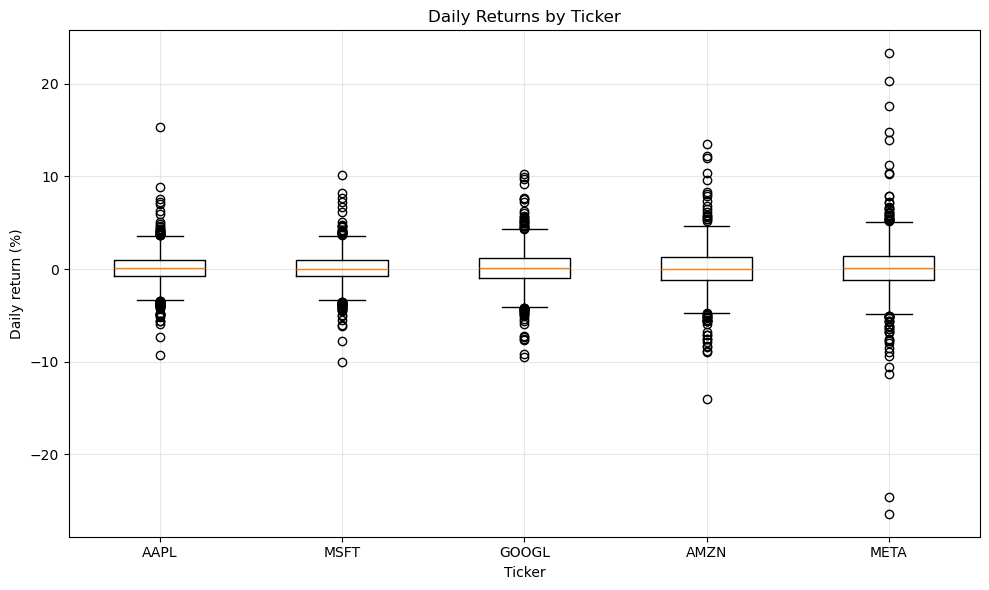

In [69]:
# Convert each ticker's returns from decimals to percentages and collect them into a list for the boxplot.
returns_for_boxplot = [returns_by_ticker[t]*100 for t in tickers]
#print(returns_for_boxplot)

plt.figure(figsize=(10, 6))
plt.boxplot(returns_for_boxplot, tick_labels=tickers, showfliers=True)
plt.title("Daily Returns by Ticker")
plt.ylabel("Daily return (%)")
plt.xlabel("Ticker")
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("insight3_boxplot.png", dpi=150)
plt.show()

Visual 2: Bar chart of mean daily returns with 95% confidence interval error bars

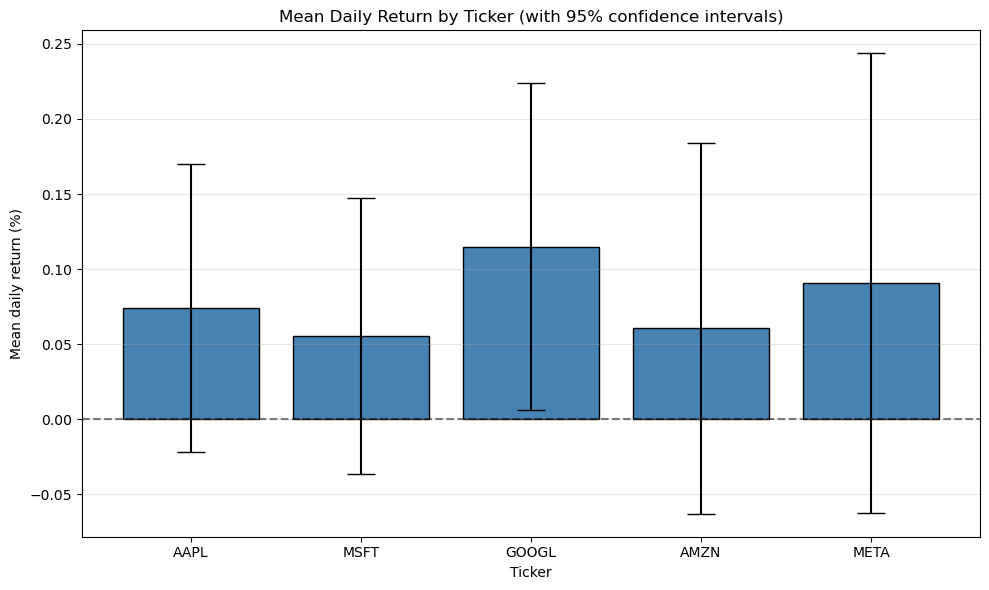

In [70]:
#For each ticker, calculate the mean daily return, standard deviation, sample size.
means = []
stds = []
n_sample = []
c_interval_95 = []
for t in tickers:
    mean = returns_by_ticker[t].mean() *100
    means.append(mean)
    #print([t]+means)
    std = returns_by_ticker[t].std() * 100
    stds.append(std)
    #print([t]+stds)
    ns = len(returns_by_ticker[t])
    n_sample.append(ns)
    #print([t]+ns)
#Calculate 95% confidence interval half-width (1.96 * std / sqrt(n)) for the error bars for each ticker.
for s, n in zip(stds, n_sample):
    ci_95 = 1.96 * s / np.sqrt(n)
    c_interval_95.append(ci_95)
#print(means)
#print(c_interval_95)
plt.figure(figsize=(10, 6))
plt.bar(tickers, means, yerr=c_interval_95, capsize=10, color="steelblue", edgecolor="black")
plt.title("Mean Daily Return by Ticker (with 95% confidence intervals)")
plt.ylabel("Mean daily return (%)")
plt.xlabel("Ticker")
plt.axhline(y=0, color="black", linestyle="--", alpha=0.5)
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
#plt.savefig("insight3_means_ci.png", dpi=150)
plt.show()

Insight 4 - Welch's Two-Sample t-test on Log Trading Volume
Question: Do Technology companies trade more actively than Financial companies on NASDAQ?
Dataset: NASDAQ_screener_clean.csv

In [71]:
#Load the cleaned NASDAQ Screener dataset
screener = read_csv("NASDAQ_screener_clean.csv")
# Keep only the two sectors we want to compare: Technology and Finance
screener = screener[screener["Sector"].isin(["Technology", "Finance"])]

In [72]:
#Quickly check for the volume distribution by comparing mean and median values
screener["Volume"].mean(), screener["Volume"].median()

(np.float64(1043398.0649017934), 60670.0)

In [73]:
#Apply log transformation to Volume because raw volume is heavily right-skewed.
#log1p computes log(1 + x), which safely handles any zero volume values.
 
screener["log_volume"] = np.log1p(screener["Volume"])

In [74]:
#Split into the two groups
 
tech_log_volume = screener.loc[screener["Sector"] == "Technology", "log_volume"]
fin_log_volume = screener.loc[screener["Sector"] == "Finance", "log_volume"]

In [75]:
#Check each group of summary statistics for the following context

print("Technology")
print(f"mean = {tech_log_volume.mean()},std = {tech_log_volume.std()}, n = {len(tech_log_volume)}")
print("Finance")
print(f"mean = {fin_log_volume.mean()}, std = {fin_log_volume.std()}, n = {len(fin_log_volume)}")

Technology
mean = 12.242831946256095,std = 2.606329294617332, n = 769
Finance
mean = 9.950810528856449, std = 2.94059754873583, n = 1573


In [76]:
#This is an independent two-sample t-test (Welch’s t-test):
t_stat, p_val = stats.ttest_ind(tech_log_volume, fin_log_volume, equal_var=False)  # Welch

#Positive t_stat → B > A
#Negative t_stat → A > B
#Bigger absolute value → stronger evidence
print("t =", t_stat, "p =", p_val)
print("mean(B) =", fin_log_volume.mean(), "mean(A) =", tech_log_volume.mean())

# (enough evidence mean are different).
isSignificant(p_val)

t = 19.146304958909234 p = 3.794537997799922e-74
mean(B) = 9.950810528856449 mean(A) = 12.242831946256095
True
Reject H₀ - the result is statistically significant


In [77]:
#Function: compute Cohen's d (effect size) for two independent samples
 
def compute_cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

In [78]:
#Calculate Cohen's d to measure the size of the difference
 
d = compute_cohens_d(tech_log_volume, fin_log_volume)
print(f"Cohen's d: {d:.3f}")

Cohen's d: 0.808


Visual 1: Boxplot of log Volume for the two sectors

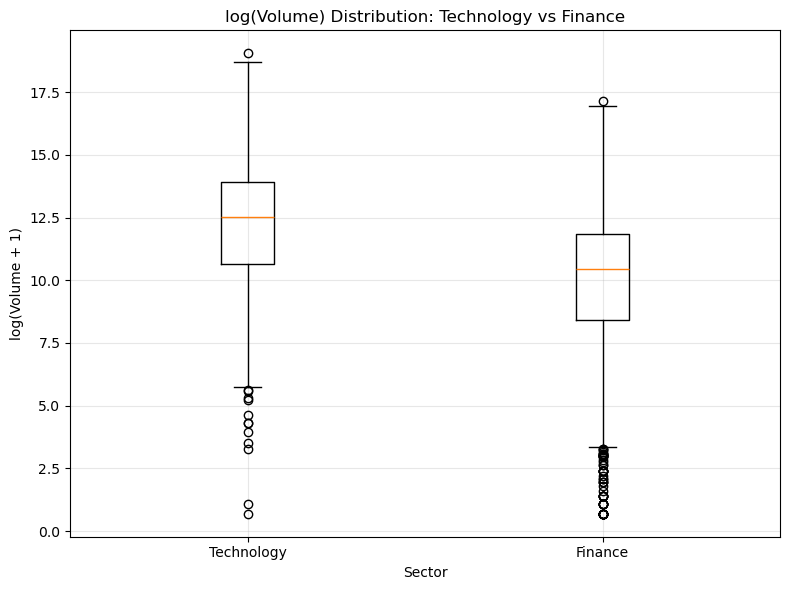

In [79]:
plt.figure(figsize=(8, 6))
plt.boxplot([tech_log_volume, fin_log_volume], tick_labels=["Technology", "Finance"], showfliers=True)
plt.title("log(Volume) Distribution: Technology vs Finance")
plt.ylabel("log(Volume + 1)")
plt.xlabel("Sector")
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("insight4_boxplot.png", dpi=150)
plt.show()

Visual 2: Overlapping histograms of log Volume for the two sectors

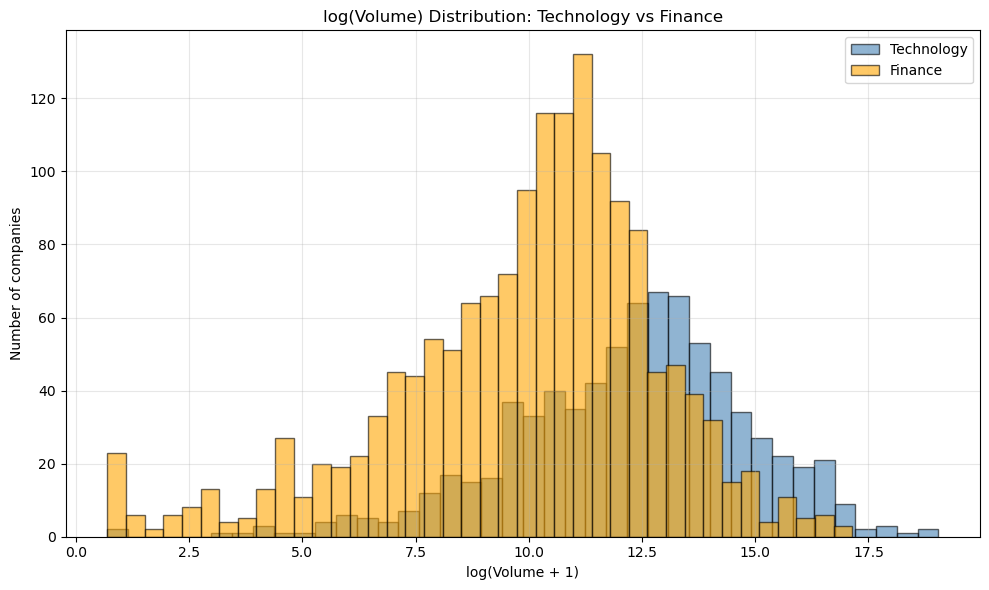

In [80]:
plt.figure(figsize=(10, 6))
plt.hist(tech_log_volume, bins=40, alpha=0.6, label="Technology", color="steelblue", edgecolor="black")
plt.hist(fin_log_volume, bins=40, alpha=0.6, label="Finance", color="orange", edgecolor="black")
plt.title("log(Volume) Distribution: Technology vs Finance")
plt.xlabel("log(Volume + 1)")
plt.ylabel("Number of companies")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("insight4_histogram.png", dpi=150)
plt.show()

Insight 5 - Multiple Linear Regression on Market Cap
Question: What predicts a company's market cap - its age, sector, or country?
Dataset: NASDAQ_screener_clean.csv

In [81]:
#Load the cleaned NASDAQ Screener dataset
screener = read_csv("NASDAQ_screener_clean.csv")
 
#Drop rows missing any column the regression needs
screener = screener.dropna(subset=["Market Cap", "IPO Year", "Sector", "Country"])


#Drop rows with non-positive Market Cap (log10 of 0 or negative is invalid)

screener = screener[screener["Market Cap"] > 0]
print(f"Sample size after dropping nulls and zero market caps: {len(screener)} companies")

Sample size after dropping nulls and zero market caps: 3107 companies


In [82]:
#Age = current year minus IPO year; current year is 2026
 
CURRENT_YEAR = 2026
screener["Age"] = CURRENT_YEAR - screener["IPO Year"]

In [83]:
#Log-transform Market Cap because raw market cap is heavily right-skewed
#log10 makes the coefficients easy to interpret as "orders of magnitude"
 
screener["log_mcap"] = np.log10(screener["Market Cap"])

In [84]:
#Function: collapse rare categories into a single "Other" bucket
#This keeps the regression manageable when one column has many small categories
 
def collapse_rare_categories(series, min_count=50):
    counts = series.value_counts()  
    keep = counts[counts >= min_count].index
    return series.where(series.isin(keep), "Other")

In [85]:
#Collapse countries that appear in fewer than 50 companies into an "Other" bucket
#Keeps the dummy-variable explosion under control
 
screener["Country"] = collapse_rare_categories(screener["Country"], min_count=50)
print(f"Unique countries after collapsing: {screener['Country'].nunique()}")

Unique countries after collapsing: 6


In [86]:
#Fit the multiple linear regression
#log10(Market Cap) is predicted by Age + Sector dummies + Country dummies
 
model = smf.ols("log_mcap ~ Age + C(Sector) + C(Country)", data=screener).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_mcap   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     36.79
Date:                Fri, 01 May 2026   Prob (F-statistic):          2.02e-110
Time:                        08:31:28   Log-Likelihood:                -4808.6
No. Observations:                3107   AIC:                             9653.
Df Residuals:                    3089   BIC:                             9762.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

Visual 1: Actual vs Predicted log10(Market Cap)
A perfect model would have all points on the diagonal red line

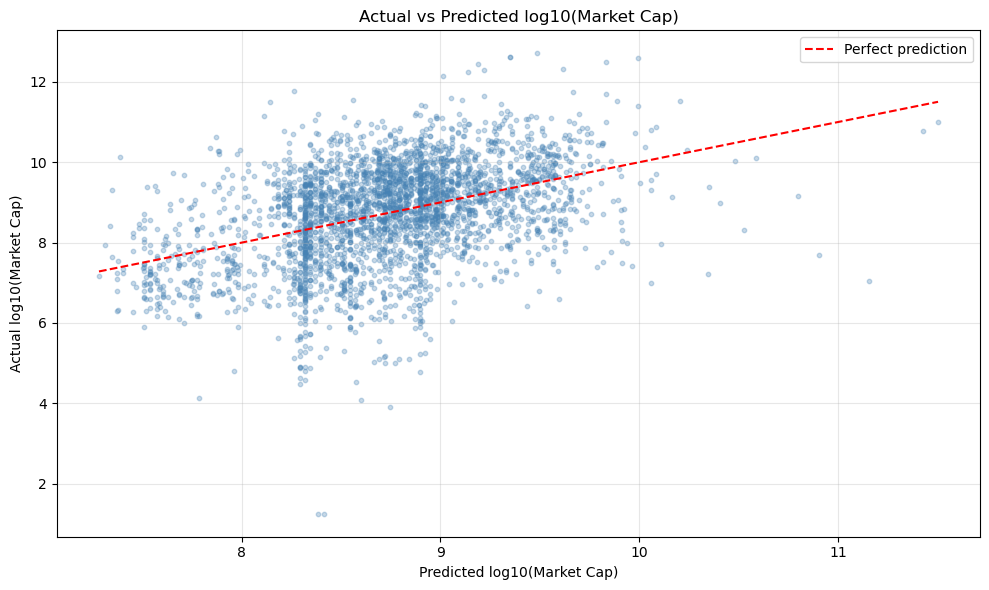

In [87]:
predicted = model.predict(screener)
 
plt.figure(figsize=(10, 6))
plt.scatter(predicted, screener["log_mcap"], alpha=0.3, s=10, color="steelblue")
plt.plot([predicted.min(), predicted.max()],
         [predicted.min(), predicted.max()],
         "r--", label="Perfect prediction")
plt.title("Actual vs Predicted log10(Market Cap)")
plt.xlabel("Predicted log10(Market Cap)")
plt.ylabel("Actual log10(Market Cap)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("insight5_actual_vs_predicted.png", dpi=150)
plt.show()


Visual 2: Coefficient forest plot with 95% confidence intervals
Shows which predictors push log market cap up or down, and by how much

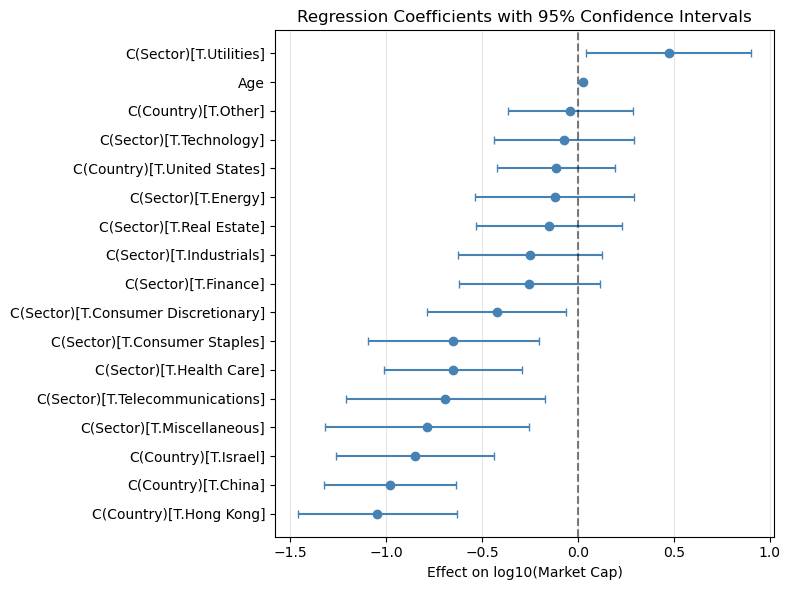

In [89]:
conf_int = model.conf_int()
conf_int.columns = ["lower", "upper"]
conf_int["estimate"] = model.params
conf_int["param"] = conf_int.index
 
# Drop the intercept since it's not a comparable predictor effect
conf_int = conf_int[conf_int["param"] != "Intercept"]
 
# Sort by estimated effect for easier reading
conf_int = conf_int.sort_values("estimate")
 
plt.figure(figsize=(8, 6))
y_pos = np.arange(len(conf_int))
plt.errorbar(
    conf_int["estimate"],
    y_pos,
    xerr=[conf_int["estimate"] - conf_int["lower"],
          conf_int["upper"] - conf_int["estimate"]],
    fmt="o",
    capsize=3,
    color="steelblue"
)
plt.yticks(y_pos, conf_int["param"])
plt.axvline(x=0, color="black", linestyle="--", alpha=0.5)
plt.title("Regression Coefficients with 95% Confidence Intervals")
plt.xlabel("Effect on log10(Market Cap)")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
#plt.savefig("insight5_coefficients.png", dpi=150)
plt.show()